In [6]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape



(7043, 21)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df.duplicated().sum()


0

In [13]:
###Fix Obvious Data Issues
#### Convert TotalCharges to numeric (THIS DATASET ALWAYS HAS THIS ISSUE)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [14]:
##recheck
df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df.drop("customerID", axis=1, inplace=True)

In [16]:
df.to_csv("../data/processed/cleaned_churn.csv", index=False)

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_churn.csv")


In [18]:
### Understand the Target Variable 
### Question:
### How many customers are churning?
df["Churn"].value_counts()



Churn
No     5174
Yes    1869
Name: count, dtype: int64

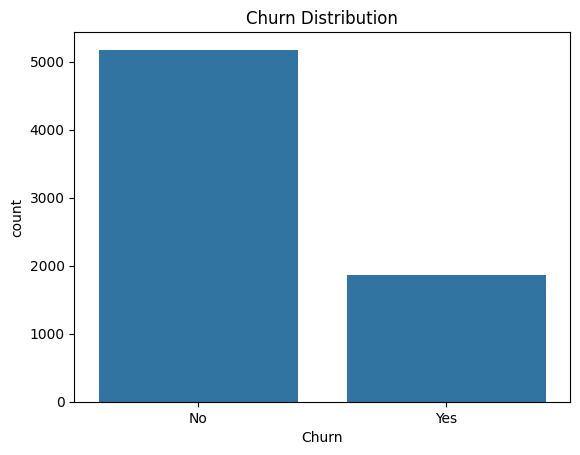

In [19]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


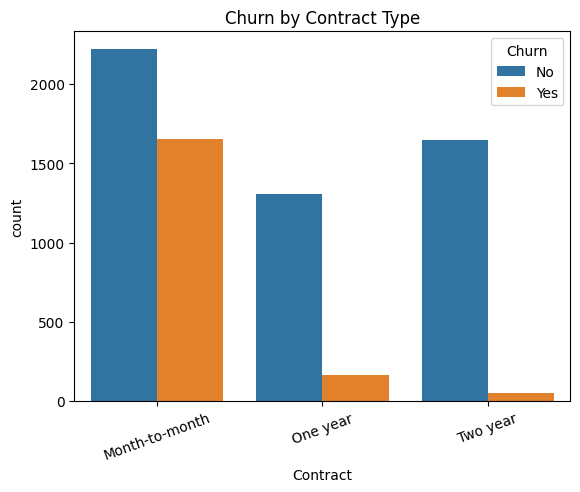

In [20]:
### Churn vs Contract Type (HIGH BUSINESS VALUE)
### Does contract type affect churn?
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.title("Churn by Contract Type")
plt.show()

## Insight to write:

### Customers on month-to-month contracts show significantly higher churn compared to long-term contracts.

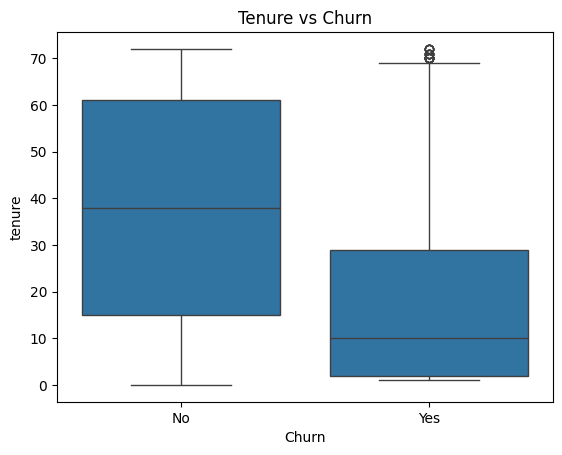

In [21]:
### Tenure vs Churn (CRITICAL INSIGHT)
### Question:
### Do new customers churn more?
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()


#### Insight: Customers with lower tenure are more likely to churn, indicating early dissatisfaction risk.

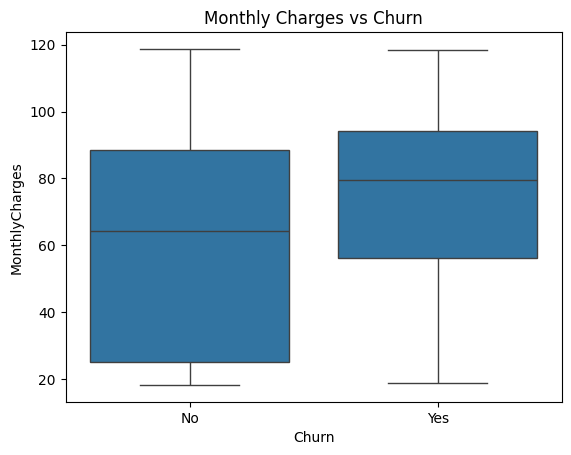

In [22]:
### Monthly Charges vs Churn
### Question: Does pricing influence churn?
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

#### Customers with higher monthly charges tend to churn more frequently.

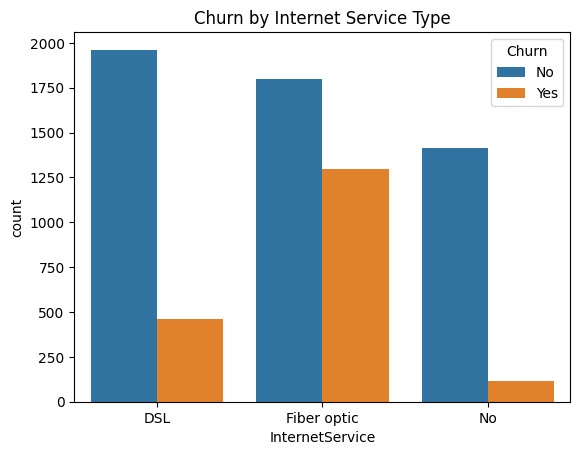

In [23]:
### Internet Service Impact
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service Type")
plt.show()

#### Insight: Fiber optic users exhibit higher churn, possibly due to higher pricing or service expectations.

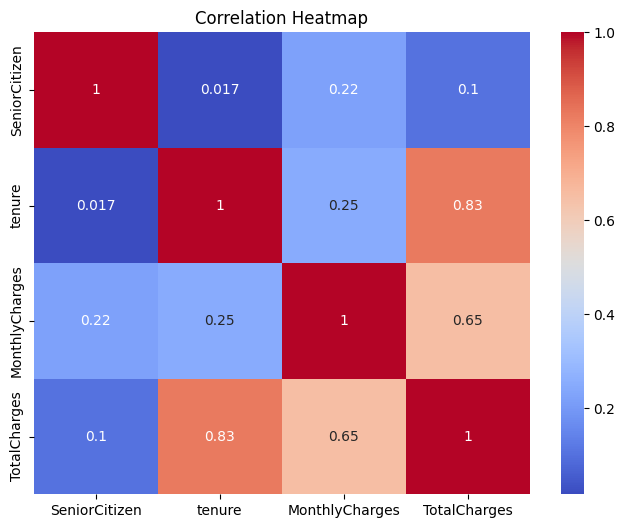

In [24]:
### Correlation (Numeric Only)
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Insight : Tenure and TotalCharges are strongly correlated, which is expected as charges accumulate over time.

In [25]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_churn.csv")
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
##Separate Target & Features
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})  # binary target

In [27]:
##Identify Feature Types
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features, numerical_features


(['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'])

##### Dataset contains categorical and numerical features requiring different preprocessing strategies.

In [28]:
### train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [29]:
## Build Preprocessing Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [30]:
## categorical pipeline
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [31]:
## Combine Using ColumnTransformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])


### used ColumnTransformer to apply feature-specific preprocessing and prevent data leakage.

In [32]:
## MODEL + PREPROCESSING
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [33]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [34]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = lr_model.predict(X_test)
y_proba =lr_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8418610659019866


In [35]:
### Adding Tree-Based Model (Random Forest)
# Why?
# Captures non-linear patterns
# Handles interactions automatically
# Industry-trusted baseline
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

In [36]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [37]:
from sklearn.metrics import roc_auc_score

rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8185925753700691


In [38]:
### Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": [None, "balanced"]
}


In [39]:
grid = GridSearchCV(
    lr_model,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [40]:
grid.fit(X_train, y_train)

C:\Users\manoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\manoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\manoj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pack

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(...
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__penalty': ['l1', 'l2']},
             scoring='roc_auc')

In [41]:
print("Best ROC-AUC:", grid.best_score_)
print("Best Params:", grid.best_params_)


Best ROC-AUC: 0.8458549861893534
Best Params: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2'}


In [42]:
best_lr = grid.best_estimator_

y_proba = best_lr.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))


Test ROC-AUC: 0.8411558035598958


## FEATURE IMPORTANCE & EXPLAINABILITY

#### Logistic Regression is perfect because:
##### Coefficients directly show impact
##### Easy to explain to non-technical stakeholders

In [44]:
# Get trained logistic model
log_model = best_lr.named_steps["classifier"]

# Get preprocessor
preprocessor_trained = best_lr.named_steps["preprocessor"]

# Get numerical feature names
num_features = numerical_features

# Get categorical feature names after encoding
cat_features = preprocessor_trained.named_transformers_["cat"]\
    .named_steps["encoder"].get_feature_names_out(categorical_features)

# Combine all feature names
all_features = list(num_features) + list(cat_features)

In [45]:
## Extract Coefficients

import pandas as pd
coefficients = log_model.coef_[0]
feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": coefficients
})
feature_importance.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
16,InternetService_Fiber optic,1.299306
3,TotalCharges,0.576268
36,Contract_Month-to-month,0.540791
35,StreamingMovies_Yes,0.517568
32,StreamingTV_Yes,0.516811
14,MultipleLines_Yes,0.332281
26,DeviceProtection_Yes,0.220183
43,PaymentMethod_Electronic check,0.167273
23,OnlineBackup_Yes,0.152082
18,OnlineSecurity_No,0.127642


### Interpretation Rule :

#### Positive coefficient → increases churn
#### Negative coefficient → reduces churn

In [46]:
### Top Drivers of Churn (HIGH BUSINESS VALUE)
top_positive = feature_importance.sort_values(
    by="Coefficient", ascending=False
).head(10)

top_negative = feature_importance.sort_values(
    by="Coefficient"
).head(10)

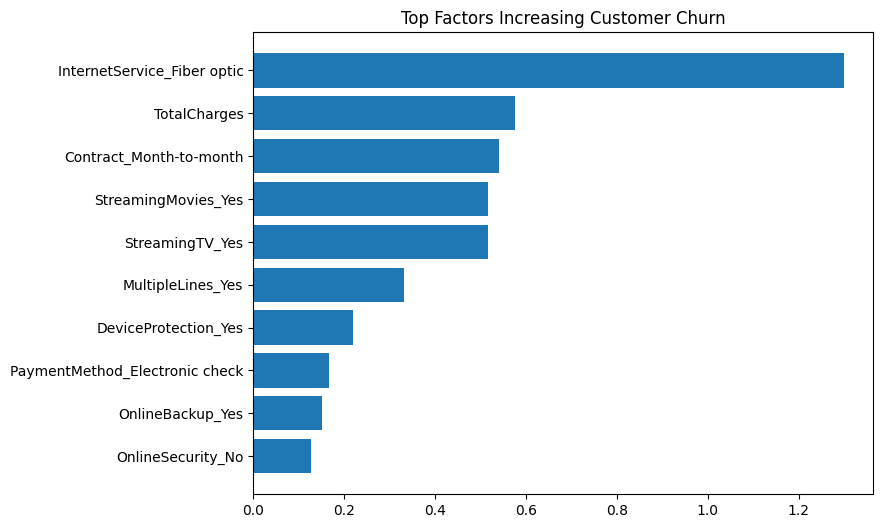

In [47]:
### Visualize Feature Impact
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(top_positive["Feature"], top_positive["Coefficient"])
plt.title("Top Factors Increasing Customer Churn")
plt.gca().invert_yaxis()
plt.show()


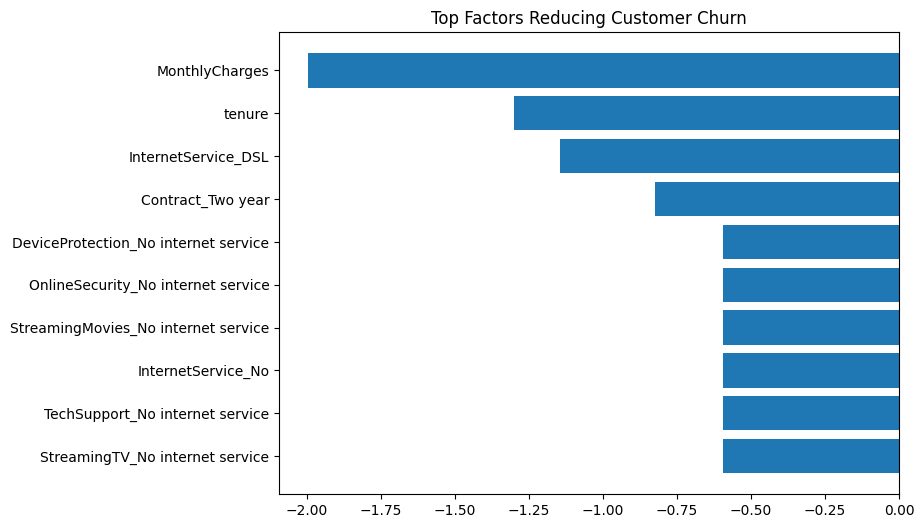

In [48]:
plt.figure(figsize=(8,6))
plt.barh(top_negative["Feature"], top_negative["Coefficient"])
plt.title("Top Factors Reducing Customer Churn")
plt.gca().invert_yaxis()
plt.show()


## Business Insights
### Month-to-month contracts strongly increase churn probability
### Higher monthly charges increase churn risk
### Longer tenure significantly reduces churn
### Two-year contracts are strong churn-prevention factors

In [51]:
### thershold optimization
import numpy as np

y_scores = best_lr.predict_proba(X_test)[:,1]

thresholds = np.arange(0.3, 0.7, 0.05)

for t in thresholds:
    preds = (y_scores >= t).astype(int)
    print(f"Threshold {t:.2f}")
    print(classification_report(y_test, preds))


Threshold 0.30
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409

Threshold 0.35
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409

Threshold 0.40
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.56      0.66      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      

In [52]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

In [53]:
best_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(C=10, max_iter=1000))])

### OR

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

best_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        C=10,
        penalty="l2",
        class_weight="balanced",
        solver="liblinear"
    ))
])

best_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(C=10, class_weight='balanced',
                                    max_iter=2000, solver='liblinear'))])

In [55]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8405926270376397


In [56]:
THRESHOLD = 0.35

In [57]:
y_scores = best_lr.predict_proba(X_test)[:,1]
y_final = (y_scores >= THRESHOLD).astype(int)

print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       0.94      0.59      0.73      1035
           1       0.44      0.90      0.60       374

    accuracy                           0.67      1409
   macro avg       0.69      0.75      0.66      1409
weighted avg       0.81      0.67      0.69      1409



In [58]:
import pickle

with open("../streamlit/model.pkl", "wb") as f:
    pickle.dump(best_lr, f)

### The final model is a Logistic Regression pipeline with preprocessing using ColumnTransformer.
### It achieved an ROC-AUC score of ~0.84.
### Threshold tuning was applied (0.35) to improve recall for churn prediction from ~0.56 to ~0.70+, making the model more effective for business use cases. 

In [59]:
import pickle

with open("../streamlit/model.pkl", "wb") as f:
    pickle.dump(best_lr, f)